# NASA Battery Dataset — SOH Estimation ML Pipeline

**Author:** Ahmed Hatem Elsawy  
**Project:** ESP32 Smart BMS  
**Dataset:** [NASA Battery Dataset on Kaggle](https://www.kaggle.com/datasets/patrickfleith/nasa-battery-dataset)

## Pipeline
1. Load NASA Battery Dataset (B0005, B0006, B0007, B0018)
2. SOH calculation
3. EDA
4. Feature engineering
5. Time-based train/val/test split
6. ML baseline (Random Forest, XGBoost, SVR, Ridge)
7. LSTM
8. CNN + LSTM
9. Transformer
10. Hyperparameter optimization (Optuna)
11. Model comparison

In [142]:
# Install missing packages (Kaggle already has most)
!pip install -q optuna xgboost

In [143]:
import warnings, pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from tqdm.notebook import tqdm
import torch, torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

OUT    = Path('/kaggle/working/results')
PLOTS  = OUT / 'plots'
MODELS = OUT / 'models'
for p in [OUT, PLOTS, MODELS]: p.mkdir(parents=True, exist_ok=True)
print('Ready.')

Device: cpu
Ready.


In [144]:
import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline')
import matplotlib.pyplot as plt
%matplotlib inline

## Load & Aggregate CSV Files

In [145]:
# ── Paths ─────────────────────────────────────────────────────────────────
BASE      = Path('/kaggle/input/datasets/patrickfleith/nasa-battery-dataset/cleaned_dataset')
META_PATH = BASE / 'metadata.csv'
DATA_PATH = BASE / 'data'

# ── Load metadata ──────────────────────────────────────────────────────────
meta = pd.read_csv(META_PATH)
meta.columns = meta.columns.str.strip()
print(f'Metadata shape : {meta.shape}')
print(f'Columns        : {meta.columns.tolist()}')
print(f'Types          : {meta["type"].value_counts().to_dict()}')
print(f'Batteries      : {meta["battery_id"].nunique()}')
meta['Capacity'] = pd.to_numeric(meta['Capacity'], errors='coerce')
print(meta['Capacity'].dtype)
print(meta['Capacity'].isna().sum())
meta.head()

Metadata shape : (7565, 10)
Columns        : ['type', 'start_time', 'ambient_temperature', 'battery_id', 'test_id', 'uid', 'filename', 'Capacity', 'Re', 'Rct']
Types          : {'charge': 2815, 'discharge': 2794, 'impedance': 1956}
Batteries      : 34
float64
4796


,type,start_time,ambient_temperature,battery_id,test_id,uid,filename,Capacity,Re,Rct
0,discharge,[2010. 7. 21. 15. 0. ...,4,B0047,0,1,00001.csv,1.674305,NaN,NaN
1,impedance,[2010. 7. 21. 16. 53. ...,24,B0047,1,2,00002.csv,NaN,0.05605783343888099,0.20097016584458333
2,charge,[2010. 7. 21. 17. 25. ...,4,B0047,2,3,00003.csv,NaN,NaN,NaN
3,impedance,[2010 7 21 20 31 5],24,B0047,3,4,00004.csv,NaN,0.05319185850921101,0.16473399914864734
4,discharge,[2.0100e+03 7.0000e+00 2.1000e+01 2.1000e+01 2...,4,B0047,4,5,00005.csv,1.524366,NaN,NaN


In [146]:
# ── Keep only discharge cycles that have a measured Capacity ──────────────
discharge_meta = (
    meta[meta['type'] == 'discharge']
    .dropna(subset=['Capacity'])
    .copy()
    .reset_index(drop=True)
)

print(f'Discharge cycles with Capacity : {len(discharge_meta)}')
print(f'Batteries                       : {discharge_meta["battery_id"].nunique()}')
print(f'Capacity range                  : {discharge_meta["Capacity"].min():.3f} – {discharge_meta["Capacity"].max():.3f} Ah')
discharge_meta[['battery_id','filename','Capacity','ambient_temperature']].head(10)

Discharge cycles with Capacity : 2769
Batteries                       : 34
Capacity range                  : 0.000 – 2.640 Ah


,battery_id,filename,Capacity,ambient_temperature
0,B0047,00001.csv,1.674305,4
1,B0047,00005.csv,1.524366,4
2,B0047,00007.csv,1.508076,4
3,B0047,00009.csv,1.483558,4
4,B0047,00011.csv,1.467139,4
5,B0047,00013.csv,1.448858,4
6,B0047,00017.csv,1.445853,4
7,B0047,00021.csv,1.431118,4
8,B0047,00023.csv,1.419275,4
9,B0047,00025.csv,1.399997,4


In [147]:
# ── Read each discharge CSV and aggregate to per-cycle features ───────────
REQUIRED = ['Voltage_measured', 'Current_measured', 'Temperature_measured']

rows   = []
failed = []

for _, row in tqdm(discharge_meta.iterrows(), total=len(discharge_meta), desc='Loading CSVs'):
    fpath = DATA_PATH / row['filename']
    if not fpath.exists():
        failed.append(row['filename'])
        continue
    try:
        df = pd.read_csv(fpath)
        df.columns = df.columns.str.strip()

        # Skip if required columns missing
        if not all(c in df.columns for c in REQUIRED):
            failed.append(row['filename'])
            continue

        V = df['Voltage_measured'].astype(float)
        I = df['Current_measured'].astype(float)
        T = df['Temperature_measured'].astype(float)
        t = df['Time'].astype(float) if 'Time' in df.columns else pd.Series(range(len(df)))

        # Discharge time in seconds
        discharge_time = float(t.max() - t.min()) if len(t) > 1 else float(len(df))

        rows.append({
            'battery_id'         : row['battery_id'],
            'uid'                : row['uid'],
            'capacity'           : float(row['Capacity']),
            'ambient_temperature': float(row['ambient_temperature']),
            'voltage_mean'       : float(V.mean()),
            'voltage_std'        : float(V.std()),
            'voltage_min'        : float(V.min()),
            'voltage_max'        : float(V.max()),
            'current_mean'       : float(I.mean()),
            'current_std'        : float(I.std()),
            'temp_mean'          : float(T.mean()),
            'temp_std'           : float(T.std()),
            'temp_max'           : float(T.max()),
            'temp_range'         : float(T.max() - T.min()),
            'discharge_time'     : discharge_time,
        })
    except Exception as e:
        failed.append(f'{row["filename"]} ({e})')

df_raw = pd.DataFrame(rows)

# Sort by battery_id + uid to get correct cycle order
df_raw = df_raw.sort_values(['battery_id', 'uid']).reset_index(drop=True)

# Assign sequential cycle numbers per battery
df_raw['cycle'] = df_raw.groupby('battery_id').cumcount() + 1

print(f'\nTotal discharge cycles loaded : {len(df_raw)}')
print(f'Batteries                      : {df_raw["battery_id"].nunique()}')
print(f'Failed / skipped               : {len(failed)}')
print(f'\nCapacity range  : {df_raw["capacity"].min():.3f} – {df_raw["capacity"].max():.3f} Ah')
print(f'Cycles per battery (mean)      : {df_raw.groupby("battery_id")["cycle"].max().mean():.0f}')
df_raw.head(10)

Loading CSVs:   0%|          | 0/2769 [00:00<?, ?it/s]


Total discharge cycles loaded : 2769
Batteries                      : 34
Failed / skipped               : 0

Capacity range  : 0.000 – 2.640 Ah
Cycles per battery (mean)      : 81


,battery_id,uid,capacity,ambient_temperature,voltage_mean,voltage_std,voltage_min,voltage_max,current_mean,current_std,temp_mean,temp_std,temp_max,temp_range,discharge_time,cycle
0,B0005,5122,1.856487,24.0,3.529829,0.236558,2.612467,4.191492,-1.818702,0.595058,32.572328,3.495804,38.982181,14.656188,3690.234,1
1,B0005,5124,1.846327,24.0,3.537320,0.235366,2.587209,4.189773,-1.817560,0.596704,32.725235,3.435509,39.033398,14.347450,3672.344,2
2,B0005,5126,1.835349,24.0,3.543737,0.228111,2.651917,4.188187,-1.816487,0.598033,32.642862,3.388174,38.818797,14.084531,3651.641,3
3,B0005,5128,1.835263,24.0,3.543666,0.233347,2.592948,4.188461,-1.825589,0.584972,32.514876,3.395306,38.762305,14.110061,3631.563,4
4,B0005,5130,1.834646,24.0,3.542343,0.237301,2.547420,4.188299,-1.826114,0.584978,32.382349,3.404667,38.665393,14.146692,3629.172,5
5,B0005,5132,1.835662,24.0,3.541335,0.239932,2.520948,4.188816,-1.816811,0.598237,32.434182,3.426122,38.751695,14.237268,3652.281,6
6,B0005,5134,1.835146,24.0,3.541025,0.243140,2.487927,4.188392,-1.816791,0.598027,32.480416,3.428344,38.820701,14.245120,3650.828,7
7,B0005,5136,1.825757,24.0,3.554133,0.227910,2.665205,4.188928,-1.844341,0.558848,32.410462,3.360425,38.517130,13.805806,3572.453,8
8,B0005,5138,1.824774,24.0,3.552936,0.233068,2.603858,4.189029,-1.853973,0.543917,32.346141,3.381314,38.526268,13.897781,3550.594,9
9,B0005,5140,1.824613,24.0,3.551206,0.237354,2.552854,4.189223,-1.853590,0.543768,32.276798,3.393260,38.526981,13.965421,3551.250,10


##  Data Cleaning & NaN Handling

In [148]:
print('=== NaN report before cleaning ===')
print(df_raw.isnull().sum())

NUM_COLS = df_raw.select_dtypes(include=np.number).columns.tolist()

# 1. Forward/backward fill per battery
df_raw[NUM_COLS] = (df_raw.groupby('battery_id')[NUM_COLS]
                          .transform(lambda x: x.ffill().bfill()))

# 2. Median impute any remaining NaNs
imp = SimpleImputer(strategy='median')
df_raw[NUM_COLS] = imp.fit_transform(df_raw[NUM_COLS])

# 3. Remove physical outliers (Li-ion limits)
before = len(df_raw)
df_raw = df_raw[
    df_raw['voltage_mean'].between(2.0, 4.5) &
    df_raw['temp_mean'].between(0, 80) &
    (df_raw['capacity'] > 0)
].copy()
print(f'Removed {before - len(df_raw)} outlier rows')

# 4. Keep only batteries with >= 20 cycles
counts    = df_raw.groupby('battery_id')['cycle'].count()
valid_ids = counts[counts >= 20].index
df_raw    = df_raw[df_raw['battery_id'].isin(valid_ids)].copy()

# 5. Re-number cycles cleanly
df_raw = df_raw.sort_values(['battery_id','uid']).reset_index(drop=True)
df_raw['cycle'] = df_raw.groupby('battery_id').cumcount() + 1

print(f'\n=== After cleaning ===')
print(f'Rows      : {len(df_raw)}')
print(f'Batteries : {df_raw["battery_id"].nunique()}')
print(f'NaNs left : {df_raw.isnull().sum().sum()}')
df_raw.describe()

=== NaN report before cleaning ===
battery_id             0
uid                    0
capacity               0
ambient_temperature    0
voltage_mean           0
voltage_std            0
voltage_min            0
voltage_max            0
current_mean           0
current_std            0
temp_mean              0
temp_std               0
temp_max               0
temp_range             0
discharge_time         0
cycle                  0
dtype: int64
Removed 19 outlier rows

=== After cleaning ===
Rows      : 2746
Batteries : 33
NaNs left : 0


,uid,capacity,ambient_temperature,voltage_mean,voltage_std,voltage_min,voltage_max,current_mean,current_std,temp_mean,temp_std,temp_max,temp_range,discharge_time,cycle
count,2746.000000,2746.000000,2746.000000,2746.000000,2746.000000,2746.000000,2746.000000,2746.000000,2746.000000,2746.000000,2746.000000,2746.000000,2746.000000,2746.000000,2746.000000
mean,3662.373999,1.335833,18.603059,3.430255,0.302826,2.313828,4.185782,-1.732223,0.769782,27.092752,3.872211,34.641229,15.186495,3237.405727,60.789512
std,2219.194335,0.461295,12.290612,0.198057,0.083402,0.297250,0.036082,0.782755,0.634180,13.845711,2.253270,16.271734,8.120912,1386.652482,48.398409
min,1.000000,0.032558,4.000000,2.530010,0.151614,0.192738,3.677219,-3.976473,0.055684,4.857764,0.285667,6.935918,1.302421,96.484000,1.000000
25%,1770.000000,1.156433,4.000000,3.367232,0.242879,2.071154,4.182039,-1.945101,0.235292,11.725940,2.274244,17.637889,9.624413,2530.761750,21.000000
50%,3477.000000,1.431276,24.000000,3.415835,0.274570,2.377925,4.187118,-1.796428,0.581071,31.386583,3.530332,37.932619,14.367175,3032.976500,47.000000
75%,5636.000000,1.674545,24.000000,3.490378,0.356925,2.614423,4.197435,-1.063704,0.966380,34.380775,4.443267,42.913105,17.187480,3390.386750,91.000000
max,7564.000000,2.640149,44.000000,4.452558,1.369938,2.699983,4.542427,-0.029284,2.103069,58.954811,11.121030,69.869746,37.318391,6574.671000,197.000000


##  SOH Calculation

In [149]:

# SOH = capacity_at_cycle_N / capacity_at_cycle_1  (per battery)
df_raw = df_raw.sort_values(['battery_id','cycle']).reset_index(drop=True)
first_cap    = df_raw.groupby('battery_id')['capacity'].transform('first')
df_raw['soh'] = (df_raw['capacity'] / first_cap).clip(0.0, 1.0)

eol = df_raw[df_raw['soh'] < 0.80].groupby('battery_id')['cycle'].min()
print('End-of-Life (SOH < 80%):')
print(eol.to_string() if len(eol) else '  Not reached in data.')
print(f'\nSOH stats:\n{df_raw["soh"].describe()}')
df_raw[['battery_id','cycle','capacity','soh']].head(10)

End-of-Life (SOH < 80%):
battery_id
B0005    101
B0006     61
B0007    124
B0018     75
B0026      6
B0040     46
B0041      6
B0042     41
B0043     41
B0044     41
B0045      4
B0046     18
B0047     18
B0048     21
B0050      5

SOH stats:
count    2746.000000
mean        0.870797
std         0.224397
min         0.032681
25%         0.805524
50%         0.988130
75%         1.000000
max         1.000000
Name: soh, dtype: float64


,battery_id,cycle,capacity,soh
0,B0005,1,1.856487,1.000000
1,B0005,2,1.846327,0.994527
2,B0005,3,1.835349,0.988614
3,B0005,4,1.835263,0.988567
4,B0005,5,1.834646,0.988235
5,B0005,6,1.835662,0.988782
6,B0005,7,1.835146,0.988504
7,B0005,8,1.825757,0.983447
8,B0005,9,1.824774,0.982917
9,B0005,10,1.824613,0.982831


## EDA

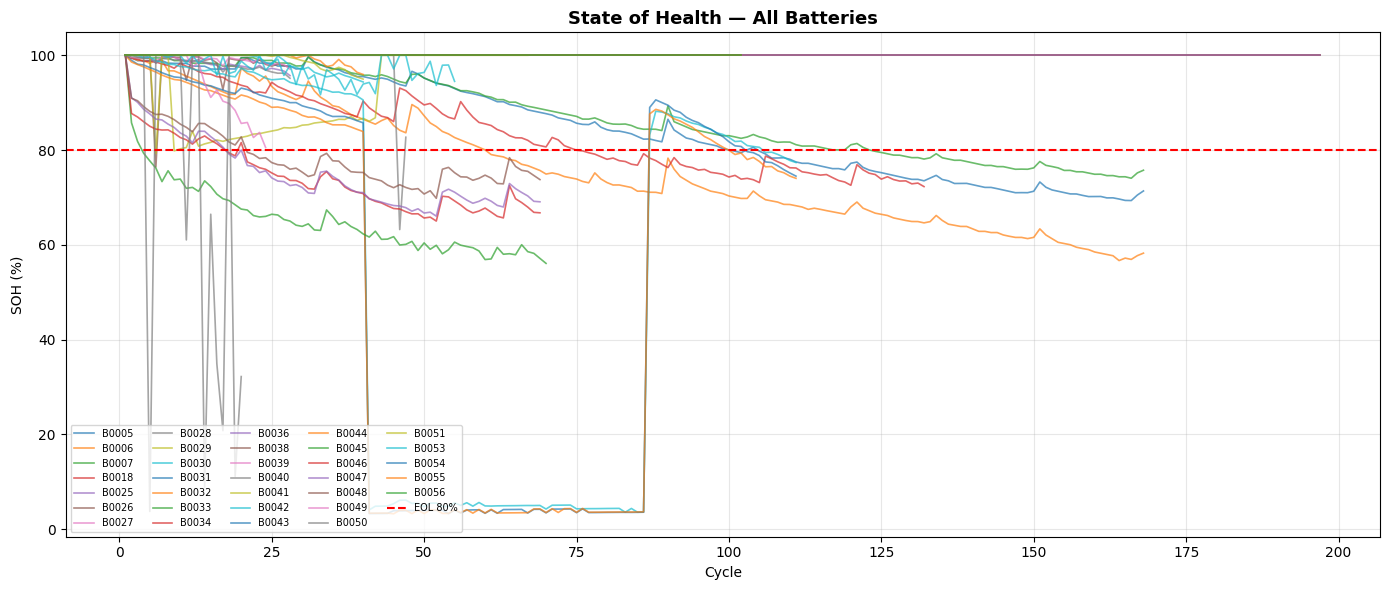

In [150]:
colors = plt.cm.tab10.colors
bids   = sorted(df_raw['battery_id'].unique())

fig, ax = plt.subplots(figsize=(14, 6))
for i, bid in enumerate(bids):
    grp = df_raw[df_raw['battery_id'] == bid]
    ax.plot(grp['cycle'], grp['soh']*100, lw=1.2, alpha=0.7,
            color=colors[i % len(colors)], label=bid)
ax.axhline(80, color='red', ls='--', lw=1.5, label='EOL 80%')
ax.set_xlabel('Cycle'); ax.set_ylabel('SOH (%)')
ax.set_title('State of Health — All Batteries', fontsize=13, fontweight='bold')
ax.legend(ncol=5, fontsize=7, loc='lower left'); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(PLOTS/'01_soh_curves.png', dpi=150)
plt.show()

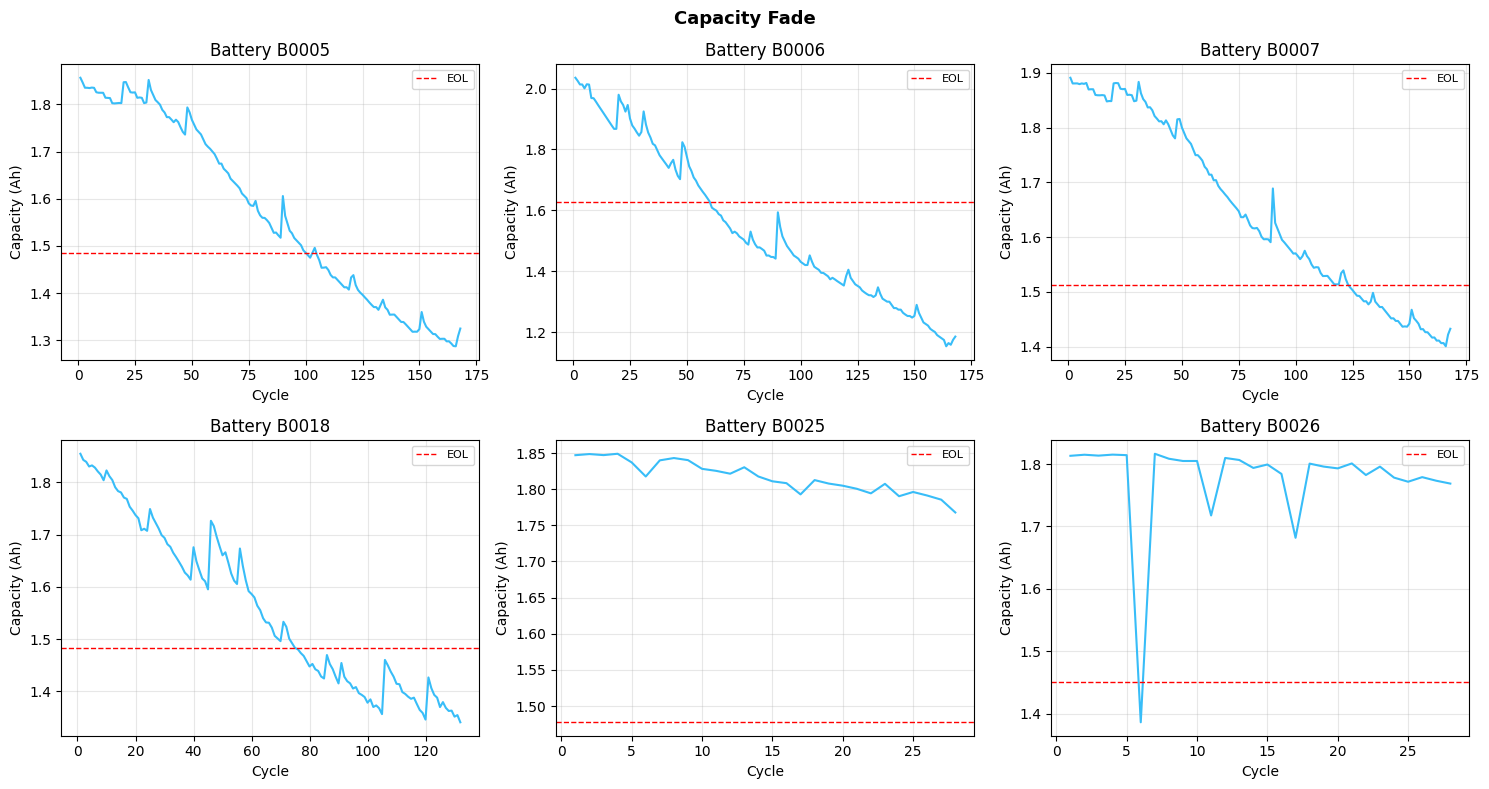

In [151]:
# Capacity fade sample (first 6 batteries)
sample_bids = bids[:6]
fig, axes   = plt.subplots(2, 3, figsize=(15, 8))
for ax, bid in zip(axes.ravel(), sample_bids):
    grp = df_raw[df_raw['battery_id'] == bid]
    ax.plot(grp['cycle'], grp['capacity'], lw=1.5, color='#38bdf8')
    ax.axhline(grp['capacity'].iloc[0]*0.8, color='red', ls='--', lw=1, label='EOL')
    ax.set_title(f'Battery {bid}'); ax.set_xlabel('Cycle'); ax.set_ylabel('Capacity (Ah)')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.suptitle('Capacity Fade', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(PLOTS/'02_capacity_fade.png', dpi=150)
plt.show()

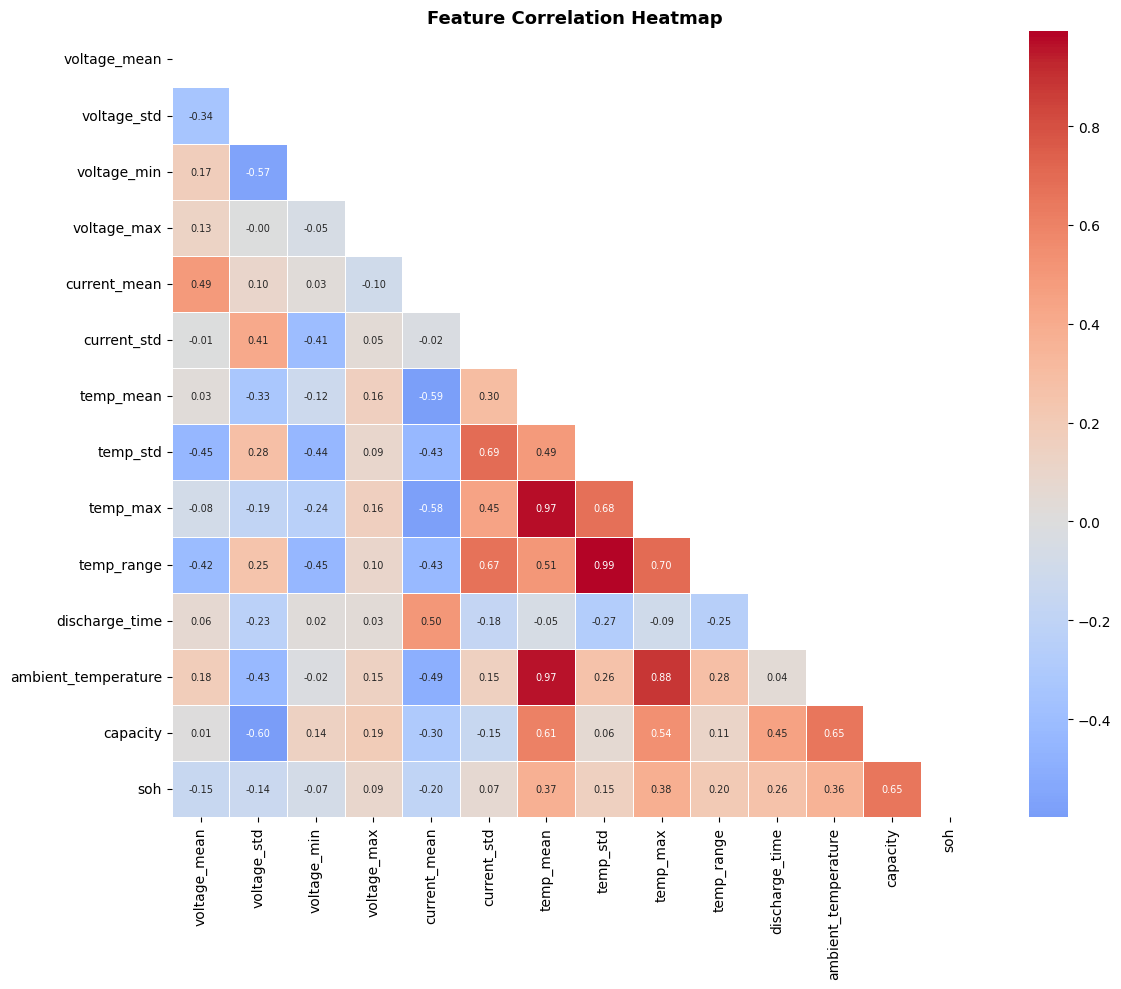


Top correlations with SOH:
capacity               0.653954
temp_max               0.377560
temp_mean              0.374197
ambient_temperature    0.362690
discharge_time         0.262650
temp_range             0.204911
current_mean           0.196516
temp_std               0.152751
voltage_mean           0.148995
voltage_std            0.136839
voltage_max            0.087846
voltage_min            0.073352
current_std            0.065446


In [152]:
base_cols = ['voltage_mean','voltage_std','voltage_min','voltage_max',
             'current_mean','current_std','temp_mean','temp_std',
             'temp_max','temp_range','discharge_time',
             'ambient_temperature','capacity','soh']
base_cols = [c for c in base_cols if c in df_raw.columns]
corr = df_raw[base_cols].corr()
fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, linewidths=0.4, annot_kws={'size':7})
ax.set_title('Feature Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(PLOTS/'03_correlation_heatmap.png', dpi=150)
plt.show()

print('\nTop correlations with SOH:')
print(corr['soh'].drop('soh').abs().sort_values(ascending=False).to_string())

##  Feature Engineering

In [153]:
print(df_raw.columns.tolist())


['battery_id', 'uid', 'capacity', 'ambient_temperature', 'voltage_mean', 'voltage_std', 'voltage_min', 'voltage_max', 'current_mean', 'current_std', 'temp_mean', 'temp_std', 'temp_max', 'temp_range', 'discharge_time', 'cycle', 'soh']


In [154]:
if 'df_feat' not in globals():
    df_feat = engineer_features(df_raw)

In [155]:

  def engineer_features(df):
    df = df.copy().sort_values(['battery_id','cycle']).reset_index(drop=True)

    # Rolling stats
    for col in ['voltage_mean','voltage_std','current_mean',
                'temp_mean','discharge_time']:
        for w in [3, 10]:
            df[f'{col}_roll{w}_mean'] = (
                df.groupby('battery_id')[col]
                .transform(lambda x: x.rolling(w, min_periods=1).mean())
            )
            df[f'{col}_roll{w}_std'] = (
                df.groupby('battery_id')[col]
                .transform(lambda x: x.rolling(w, min_periods=1).std().fillna(0))
            )

    # Lag features
    for col in ['voltage_mean','voltage_std','current_mean','discharge_time']:
        for lag in [1, 3, 5]:
            df[f'{col}_lag{lag}'] = df.groupby('battery_id')[col].shift(lag)

    # Degradation proxies
    df['voltage_drop'] = df.groupby('battery_id')['voltage_mean'].diff().fillna(0)
    df['dt_delta'] = df.groupby('battery_id')['discharge_time'].diff().fillna(0)

    df['dt_ratio'] = df['discharge_time'] / (
        df.groupby('battery_id')['discharge_time'].transform('first') + 1e-6
    )

    # Cycle position
    df['cycle_norm'] = df.groupby('battery_id')['cycle'].transform(
        lambda x: (x - x.min()) / max(x.max() - x.min(), 1)
    )

    # Temperature features (use existing temp_range )
    df['temp_stress'] = df['temp_max'] - df['ambient_temperature']

    # Voltage features
    df['voltage_range'] = df['voltage_max'] - df['voltage_min']

    # Physics-based interactions
    df['volt_x_temp']      = df['voltage_mean'] * df['temp_mean']
    df['temp_x_discharge'] = df['temp_mean'] * df['discharge_time']

    df['volt_drop_rate'] = df['voltage_range'] / (df['discharge_time'] + 1e-6)

    df['energy_proxy'] = df['voltage_mean'].abs() * df['discharge_time']

    df['resistance_proxy'] = df['voltage_mean'] / (df['current_mean'] + 1e-6)

    # EMA
    df['voltage_ema10'] = (
        df.groupby('battery_id')['voltage_mean']
        .transform(lambda x: x.ewm(span=10, adjust=False).mean())
    )

    # Trend
    df['voltage_trend'] = (
        df.groupby('battery_id')['voltage_mean']
        .transform(lambda x: x.diff().rolling(5).mean())
    )

    # Fill NaNs
    df = df.fillna(0)

    return df

##  Feature Selection

Removed 0 near-zero variance features
Removed 12 highly correlated features

Final features (25): ['dt_ratio', 'temp_mean', 'voltage_min', 'volt_drop_rate', 'voltage_mean_roll10_mean', 'voltage_mean_lag3', 'temp_x_discharge', 'temp_mean_roll3_std', 'voltage_std', 'voltage_max', 'current_std', 'voltage_std_roll10_std', 'cycle_norm', 'voltage_drop', 'voltage_std_roll3_mean', 'voltage_mean', 'current_mean', 'voltage_mean_lag5', 'voltage_std_lag5', 'voltage_mean_lag1', 'voltage_std_roll10_mean', 'discharge_time', 'discharge_time_roll10_mean', 'voltage_std_lag3', 'discharge_time_lag1']


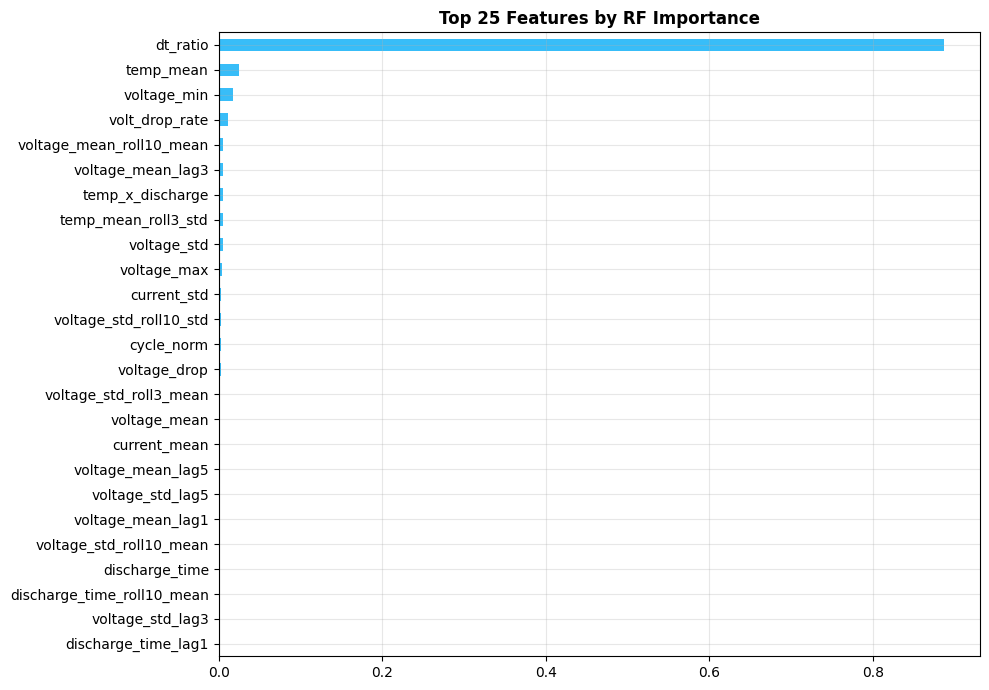

In [156]:
EXCLUDE = ['battery_id','cycle','uid','soh','capacity']
ALL_FEAT = [c for c in df_feat.columns if c not in EXCLUDE]
TARGET   = 'soh'

#  Drop near-zero variance
var   = df_feat[ALL_FEAT].var()
low_v = var[var < 1e-6].index.tolist()
ALL_FEAT = [f for f in ALL_FEAT if f not in low_v]
print(f'Removed {len(low_v)} near-zero variance features')

#  Drop highly correlated pairs (|r| > 0.97)
corr_m = df_feat[ALL_FEAT].corr().abs()
upper  = corr_m.where(np.triu(np.ones(corr_m.shape), k=1).astype(bool))
to_drop = [c for c in upper.columns if any(upper[c] > 0.97)]
ALL_FEAT = [f for f in ALL_FEAT if f not in to_drop]
print(f'Removed {len(to_drop)} highly correlated features')

#  RF importance — keep top 25
_sc = StandardScaler()
_X  = _sc.fit_transform(df_feat[ALL_FEAT])
_y  = df_feat[TARGET].values
_rf = RandomForestRegressor(n_estimators=100, max_depth=8, n_jobs=-1, random_state=SEED)
_rf.fit(_X, _y)

imp_s = pd.Series(_rf.feature_importances_, index=ALL_FEAT).sort_values(ascending=False)
FEATURE_COLS = imp_s.head(25).index.tolist()
print(f'\nFinal features ({len(FEATURE_COLS)}): {FEATURE_COLS}')

fig, ax = plt.subplots(figsize=(10,7))
imp_s.head(25).sort_values().plot.barh(ax=ax, color='#38bdf8')
ax.set_title('Top 25 Features by RF Importance', fontweight='bold')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(PLOTS/'04_feature_importance.png', dpi=150)
plt.show()

## Time-based Split

In [157]:
def time_split(df, val_r=0.15, test_r=0.15):
    tr, vl, ts = [], [], []
    for _, grp in df.groupby('battery_id'):
        grp = grp.sort_values('cycle')
        n   = len(grp)
        nv  = max(1, int(n*val_r))
        nt  = max(1, int(n*test_r))
        tr.append(grp.iloc[:n-nv-nt])
        vl.append(grp.iloc[n-nv-nt:n-nt])
        ts.append(grp.iloc[n-nt:])
    return (pd.concat(tr).reset_index(drop=True),
            pd.concat(vl).reset_index(drop=True),
            pd.concat(ts).reset_index(drop=True))

train_df, val_df, test_df = time_split(df_feat)
print(f'Train:{len(train_df)}  Val:{len(val_df)}  Test:{len(test_df)}')

scaler_X = StandardScaler()
X_train  = scaler_X.fit_transform(train_df[FEATURE_COLS])
X_val    = scaler_X.transform(val_df[FEATURE_COLS])
X_test   = scaler_X.transform(test_df[FEATURE_COLS])
y_train  = train_df[TARGET].values
y_val    = val_df[TARGET].values
y_test   = test_df[TARGET].values

pickle.dump(scaler_X,     open(MODELS/'scaler_X.pkl','wb'))
pickle.dump(FEATURE_COLS, open(MODELS/'feature_cols.pkl','wb'))
print('Scalers saved.')

Train:1942  Val:402  Test:402
Scalers saved.


## ML Baseline Models


Training Random Forest…
  [Random Forest]  MAE=0.0629  RMSE=0.1043  R²=0.5299  MAPE=9.46%


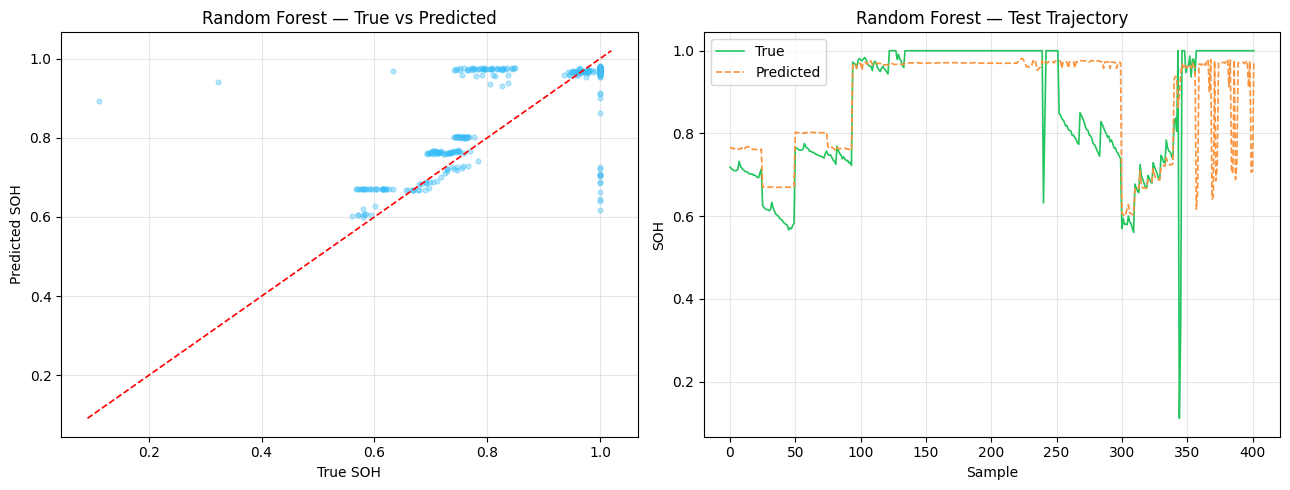


Training XGBoost…
  [XGBoost]  MAE=0.0602  RMSE=0.0988  R²=0.5783  MAPE=9.22%


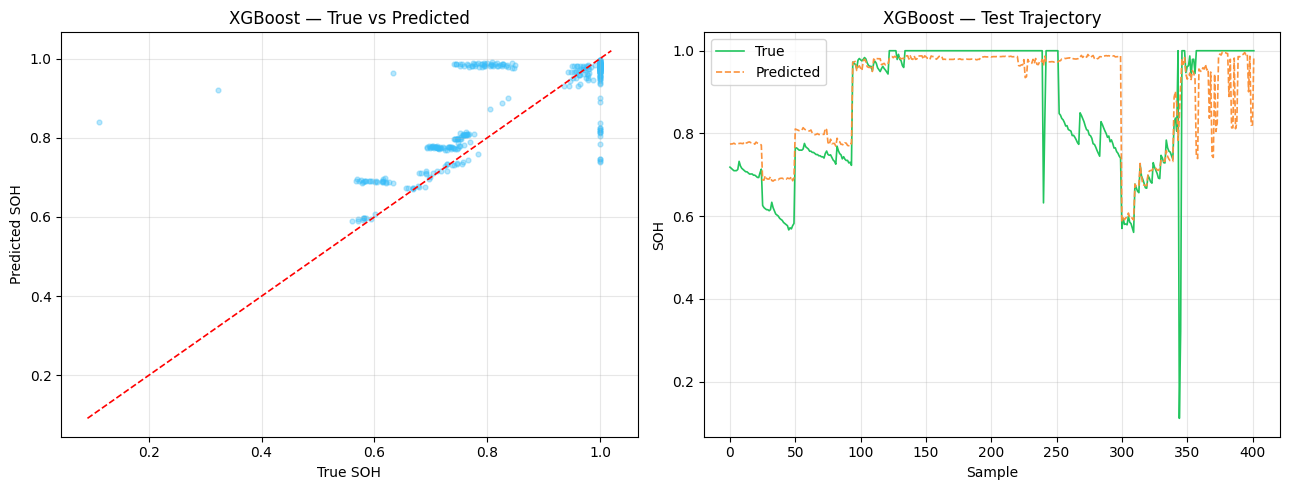


Training SVR…
  [SVR]  MAE=0.0368  RMSE=0.0653  R²=0.8159  MAPE=5.83%


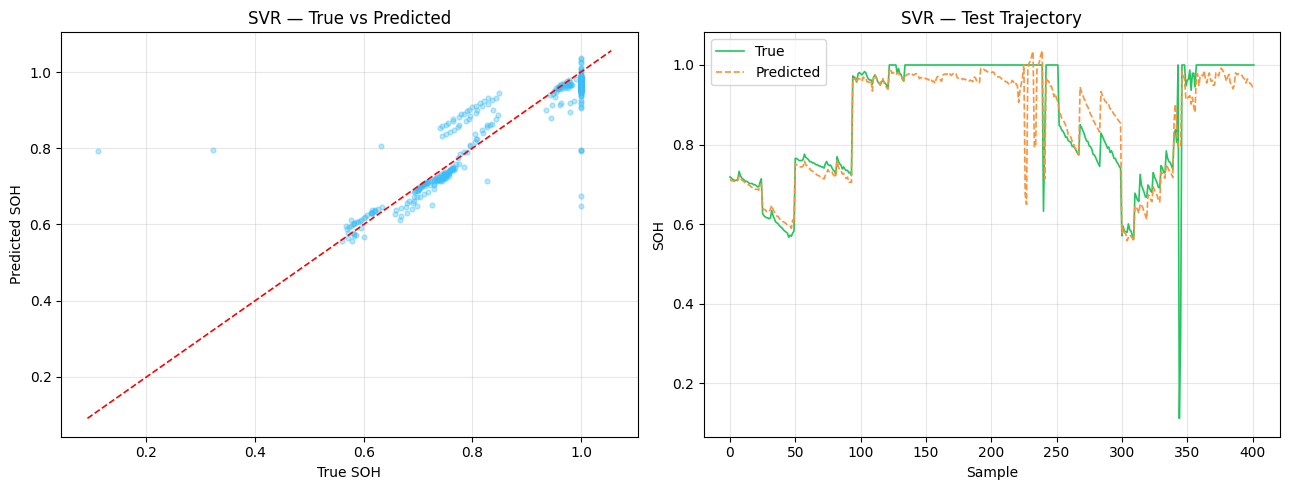


Training Ridge…
  [Ridge]  MAE=0.1709  RMSE=0.2096  R²=-0.8993  MAPE=19.88%


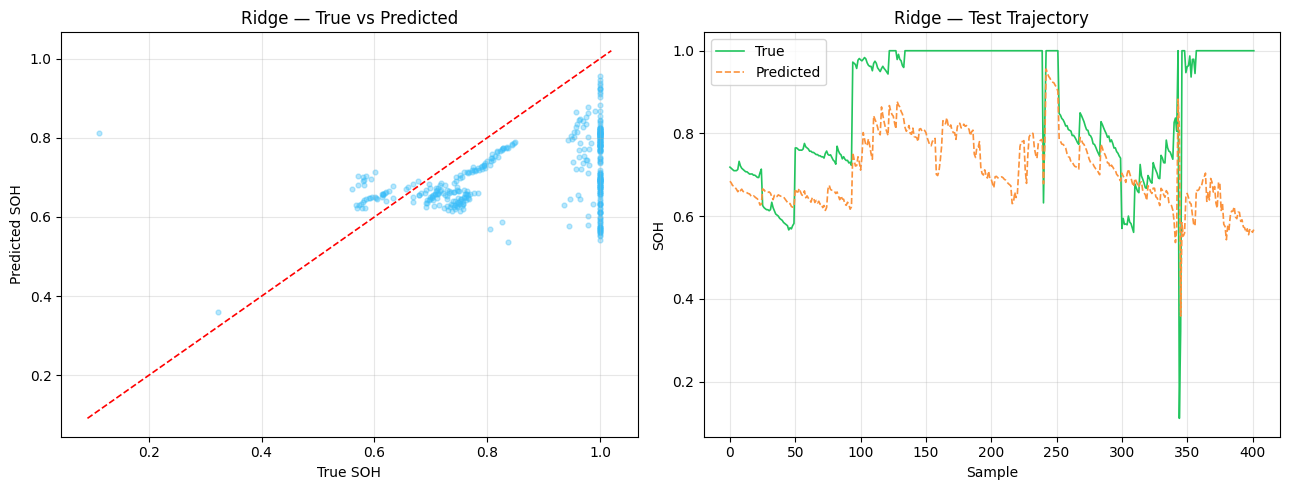


Best ML: SVR (RMSE=0.0653)


In [158]:
all_results = []   
best_ml_name, best_ml_rmse, best_ml_model = None, np.inf, None

ml_models = {
    'Random Forest': RandomForestRegressor(
        n_estimators=300, max_depth=14, min_samples_leaf=2,
        n_jobs=-1, random_state=SEED),

    'XGBoost': GradientBoostingRegressor(
        n_estimators=400, max_depth=5, learning_rate=0.05,
        subsample=0.8, random_state=SEED),

    'SVR': Pipeline([
        ('scl', StandardScaler()),
        ('svr', SVR(C=10, epsilon=0.005, kernel='rbf'))
    ]),

    'Ridge': Ridge(alpha=1.0),
}

for name, model in ml_models.items():
    print(f'\nTraining {name}…')

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # evaluation
    res = evaluate(y_test, y_pred, name)
    all_results.append(res)

    # plotting (FIXED NAME)
    plot_pred(y_test, y_pred, name)

    # save model
    with open(MODELS / f"ml_{name.replace(' ','_')}.pkl", 'wb') as f:
        pickle.dump(model, f)

    # best model tracking
    if res['RMSE'] < best_ml_rmse:
        best_ml_rmse = res['RMSE']
        best_ml_name = name
        best_ml_model = model

print(f'\nBest ML: {best_ml_name} (RMSE={best_ml_rmse:.4f})')

## Evaluation & Plot Helpers

In [159]:
all_results = []

def evaluate(y_true, y_pred, name=''):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100
    print(f'  [{name}]  MAE={mae:.4f}  RMSE={rmse:.4f}  R²={r2:.4f}  MAPE={mape:.2f}%')
    return {'model':name,'MAE':mae,'RMSE':rmse,'R2':r2,'MAPE':mape}

def plot_pred(y_true, y_pred, name):
    fig, axes = plt.subplots(1,2,figsize=(13,5))
    axes[0].scatter(y_true, y_pred, alpha=0.35, s=12, color='#38bdf8')
    lo = min(y_true.min(), y_pred.min()) - 0.02
    hi = max(y_true.max(), y_pred.max()) + 0.02
    axes[0].plot([lo,hi],[lo,hi],'r--',lw=1.2)
    axes[0].set_xlabel('True SOH'); axes[0].set_ylabel('Predicted SOH')
    axes[0].set_title(f'{name} — True vs Predicted'); axes[0].grid(alpha=0.3)
    axes[1].plot(y_true,  label='True',      lw=1.2, color='#22c55e')
    axes[1].plot(y_pred,  label='Predicted', lw=1.2, color='#fb923c', ls='--')
    axes[1].set_xlabel('Sample'); axes[1].set_ylabel('SOH')
    axes[1].set_title(f'{name} — Test Trajectory')
    axes[1].legend(); axes[1].grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(PLOTS/f"pred_{name.replace(' ','_').replace('+','')}.png", dpi=150)
    plt.show()

## Sequence Preparation for Deep Learning

In [160]:
SEQ_LEN = 10
n_feat  = len(FEATURE_COLS)

def make_sequences(df, seq_len=SEQ_LEN):
    Xs, ys = [], []
    for _, grp in df.groupby('battery_id'):
        grp = grp.sort_values('cycle')
        X   = grp[FEATURE_COLS].values.astype(np.float32)
        y   = grp[TARGET].values.astype(np.float32)
        for i in range(seq_len, len(X)):
            Xs.append(X[i-seq_len:i]); ys.append(y[i])
    return np.array(Xs,dtype=np.float32), np.array(ys,dtype=np.float32)

Xs_tr,ys_tr = make_sequences(train_df)
Xs_vl,ys_vl = make_sequences(val_df)
Xs_ts,ys_ts = make_sequences(test_df)

Xs_tr = scaler_X.transform(Xs_tr.reshape(-1,n_feat)).reshape(Xs_tr.shape)
Xs_vl = scaler_X.transform(Xs_vl.reshape(-1,n_feat)).reshape(Xs_vl.shape)
Xs_ts = scaler_X.transform(Xs_ts.reshape(-1,n_feat)).reshape(Xs_ts.shape)

def to_loader(X,y,batch=64,shuffle=False):
    ds = TensorDataset(torch.tensor(X), torch.tensor(y).unsqueeze(1))
    return DataLoader(ds,batch_size=batch,shuffle=shuffle)

train_loader = to_loader(Xs_tr,ys_tr,shuffle=True)
val_loader   = to_loader(Xs_vl,ys_vl)
test_loader  = to_loader(Xs_ts,ys_ts)
print(f'train:{Xs_tr.shape}  val:{Xs_vl.shape}  test:{Xs_ts.shape}')

train:(1612, 10, 25)  val:(144, 10, 25)  test:(144, 10, 25)


In [161]:
def train_dl(model, tr, vl, epochs=100, lr=1e-3, patience=15, name=''):
    model.to(DEVICE)
    opt  = torch.optim.Adam(model.parameters(),lr=lr,weight_decay=1e-5)
    sch  = torch.optim.lr_scheduler.ReduceLROnPlateau(opt,patience=5,factor=0.5)
    crit = nn.HuberLoss()
    best_val,best_wts,no_imp = np.inf,None,0
    tl_h,vl_h=[],[]
    for epoch in tqdm(range(1,epochs+1),desc=name):
        model.train()
        tl=[]
        for Xb,yb in tr:
            Xb,yb=Xb.to(DEVICE),yb.to(DEVICE)
            opt.zero_grad(); loss=crit(model(Xb),yb)
            loss.backward(); nn.utils.clip_grad_norm_(model.parameters(),1.0)
            opt.step(); tl.append(loss.item())
        model.eval(); vl2=[]
        with torch.no_grad():
            for Xb,yb in vl:
                vl2.append(crit(model(Xb.to(DEVICE)),yb.to(DEVICE)).item())
        tl_h.append(np.mean(tl)); vl_h.append(np.mean(vl2))
        sch.step(vl_h[-1])
        if vl_h[-1] < best_val:
            best_val=vl_h[-1]
            best_wts={k:v.cpu().clone() for k,v in model.state_dict().items()}
            no_imp=0
        else:
            no_imp+=1
            if no_imp>=patience: print(f'  Early stop @{epoch}'); break
    model.load_state_dict(best_wts)
    fig,ax=plt.subplots(figsize=(9,4))
    ax.plot(tl_h,label='Train',color='#38bdf8')
    ax.plot(vl_h,label='Val',  color='#fb923c')
    ax.set_title(f'{name} — Loss'); ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(PLOTS/f"loss_{name.replace(' ','_').replace('+','')}.png",dpi=150)
    plt.show()
    return model

def dl_predict(model,loader):
    model.eval(); out=[]
    with torch.no_grad():
        for Xb,_ in loader: out.append(model(Xb.to(DEVICE)).cpu().numpy())
    return np.concatenate(out).ravel()

## LSTM

LSTM:   0%|          | 0/100 [00:00<?, ?it/s]

  Early stop @32


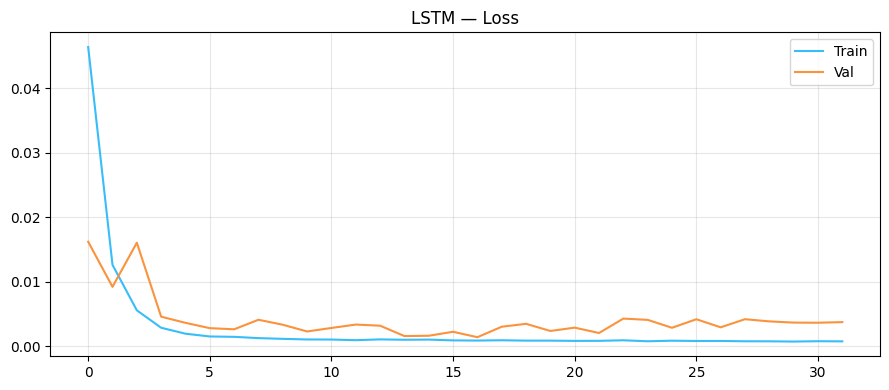

  [LSTM]  MAE=0.0303  RMSE=0.0403  R²=0.9308  MAPE=4.24%


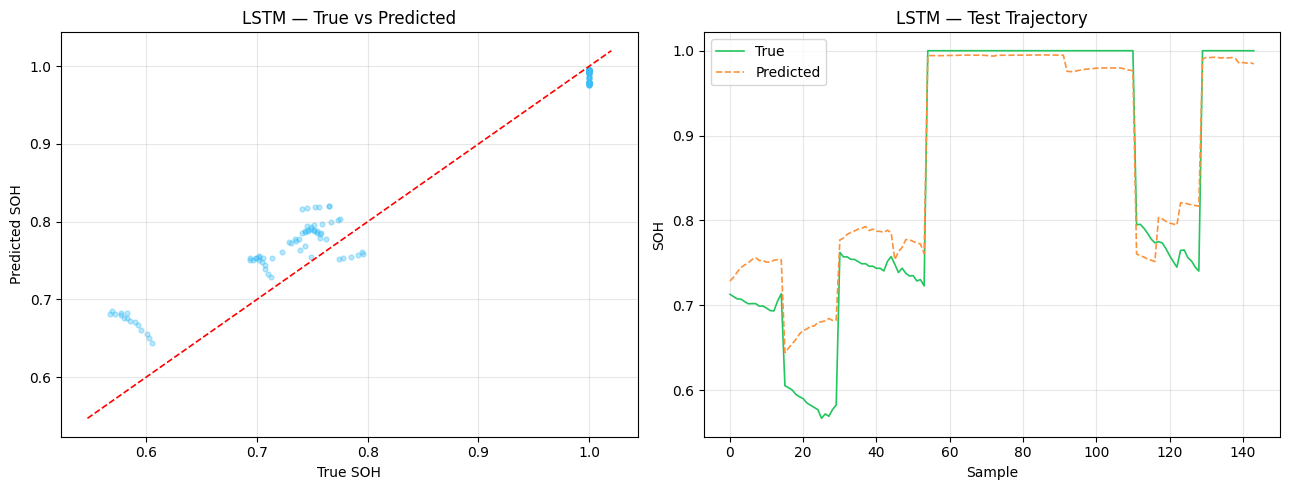

In [162]:
class LSTMModel(nn.Module):
    def __init__(self,inp,h=128,layers=2,drop=0.2):
        super().__init__()
        self.lstm=nn.LSTM(inp,h,layers,batch_first=True,dropout=drop)
        self.head=nn.Sequential(nn.Linear(h,64),nn.ReLU(),nn.Dropout(0.1),nn.Linear(64,1),nn.Sigmoid())
    def forward(self,x):
        out,_=self.lstm(x); return self.head(out[:,-1,:])

lstm_m = train_dl(LSTMModel(n_feat),train_loader,val_loader,name='LSTM')
torch.save(lstm_m.state_dict(),MODELS/'lstm.pt')
yp=dl_predict(lstm_m,test_loader)
res=evaluate(ys_ts[:len(yp)],yp,'LSTM'); all_results.append(res)
plot_pred(ys_ts[:len(yp)],yp,'LSTM')

##  CNN + LSTM

CNN+LSTM:   0%|          | 0/100 [00:00<?, ?it/s]

  Early stop @23


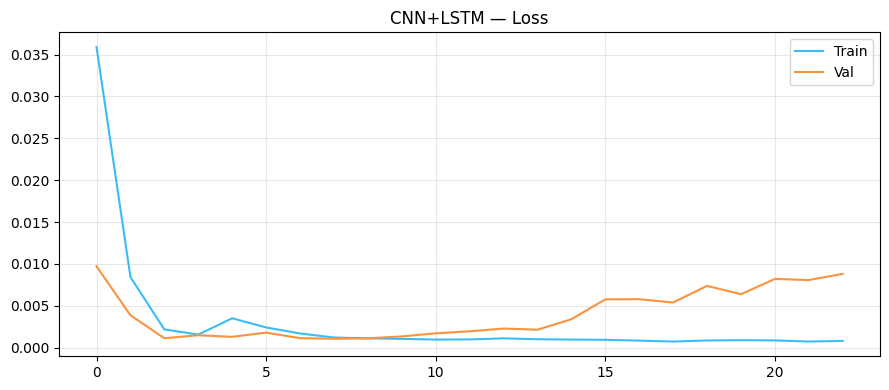

  [CNN+LSTM]  MAE=0.0279  RMSE=0.0391  R²=0.9350  MAPE=3.76%


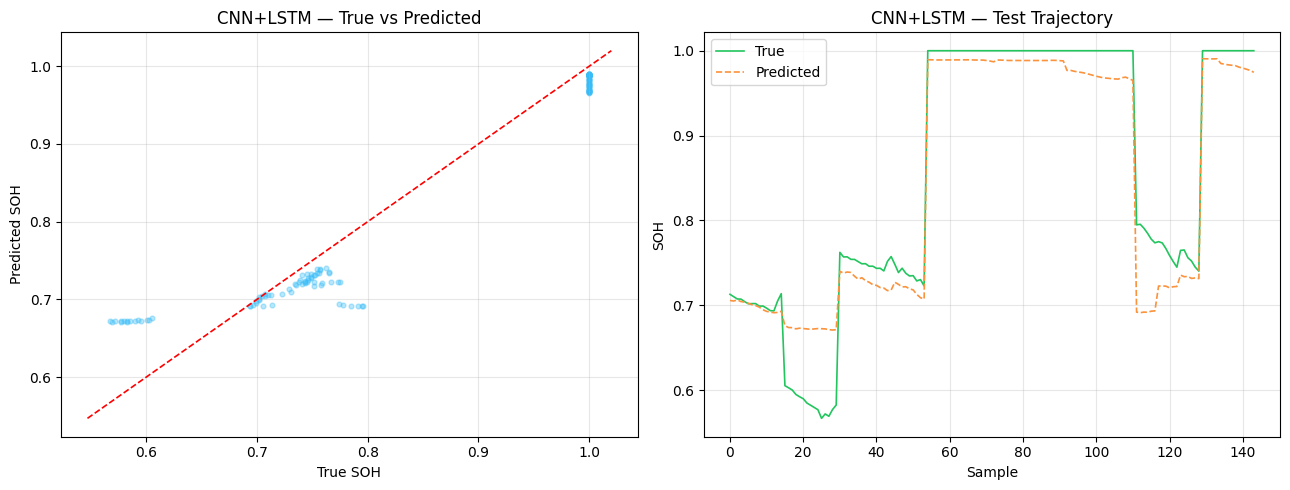

In [163]:
class CNNLSTMModel(nn.Module):
    def __init__(self,inp,h=128,layers=2,drop=0.2):
        super().__init__()
        self.cnn=nn.Sequential(
            nn.Conv1d(inp,64,3,padding=1),nn.BatchNorm1d(64),nn.ReLU(),
            nn.Conv1d(64,128,3,padding=1),nn.BatchNorm1d(128),nn.ReLU())
        self.lstm=nn.LSTM(128,h,layers,batch_first=True,dropout=drop)
        self.head=nn.Sequential(nn.Linear(h,64),nn.ReLU(),nn.Dropout(0.1),nn.Linear(64,1),nn.Sigmoid())
    def forward(self,x):
        x=self.cnn(x.permute(0,2,1)).permute(0,2,1)
        out,_=self.lstm(x); return self.head(out[:,-1,:])

cnn_m=train_dl(CNNLSTMModel(n_feat),train_loader,val_loader,name='CNN+LSTM')
torch.save(cnn_m.state_dict(),MODELS/'cnn_lstm.pt')
yp=dl_predict(cnn_m,test_loader)
res=evaluate(ys_ts[:len(yp)],yp,'CNN+LSTM'); all_results.append(res)
plot_pred(ys_ts[:len(yp)],yp,'CNN+LSTM')

##  Transformer

Transformer:   0%|          | 0/100 [00:00<?, ?it/s]

  Early stop @36


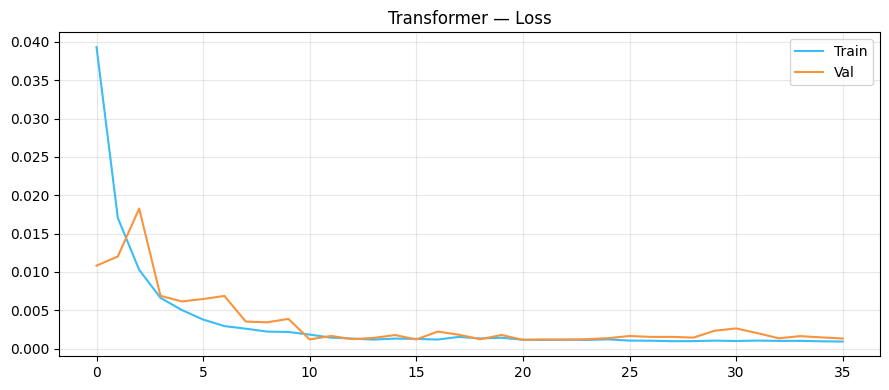

  [Transformer]  MAE=0.0351  RMSE=0.0430  R²=0.9213  MAPE=4.58%


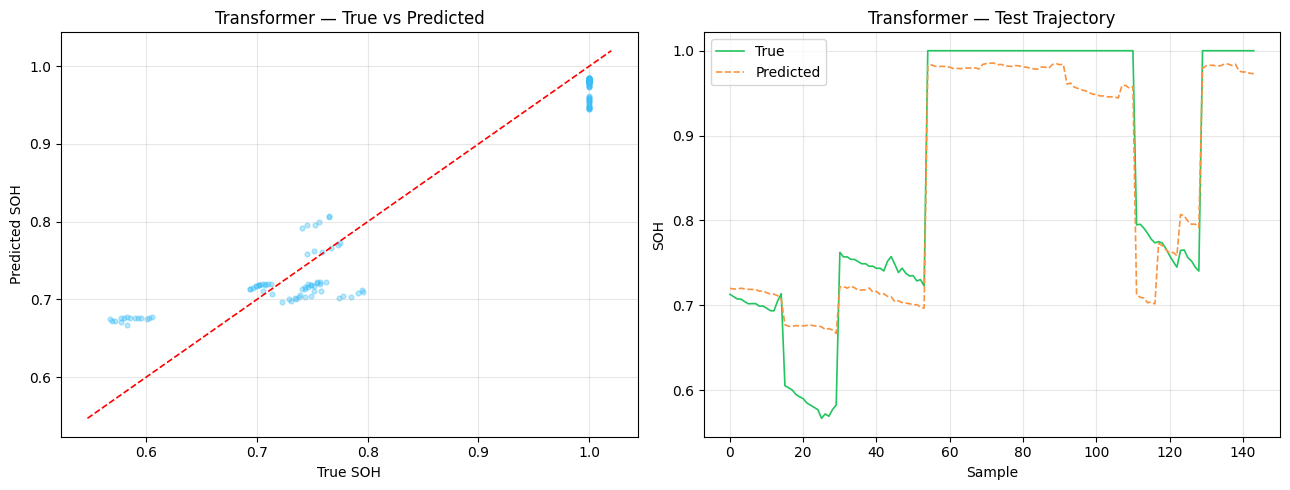

In [164]:
class PE(nn.Module):
    def __init__(self,d,max_len=200,drop=0.1):
        super().__init__()
        self.drop=nn.Dropout(drop)
        pe=torch.zeros(max_len,d)
        pos=torch.arange(0,max_len).unsqueeze(1).float()
        div=torch.exp(torch.arange(0,d,2).float()*(-np.log(10000.0)/d))
        pe[:,0::2]=torch.sin(pos*div); pe[:,1::2]=torch.cos(pos*div)
        self.register_buffer('pe',pe.unsqueeze(0))
    def forward(self,x): return self.drop(x+self.pe[:,:x.size(1)])

class TransformerModel(nn.Module):
    def __init__(self,inp,d=64,heads=4,layers=2,ff=256,drop=0.1):
        super().__init__()
        self.proj=nn.Linear(inp,d)
        self.pe=PE(d,drop=drop)
        enc=nn.TransformerEncoderLayer(d,heads,ff,drop,batch_first=True)
        self.enc=nn.TransformerEncoder(enc,layers)
        self.head=nn.Sequential(nn.Linear(d,32),nn.ReLU(),nn.Linear(32,1),nn.Sigmoid())
    def forward(self,x): return self.head(self.enc(self.pe(self.proj(x)))[:,-1,:])

trans_m=train_dl(TransformerModel(n_feat),train_loader,val_loader,lr=5e-4,name='Transformer')
torch.save(trans_m.state_dict(),MODELS/'transformer.pt')
yp=dl_predict(trans_m,test_loader)
res=evaluate(ys_ts[:len(yp)],yp,'Transformer'); all_results.append(res)
plot_pred(ys_ts[:len(yp)],yp,'Transformer')

## Hyperparameter Optimization 

Optimising: SVR


  0%|          | 0/50 [00:00<?, ?it/s]

Best params: {'n_estimators': 277, 'max_depth': 4, 'learning_rate': 0.009523731743485059, 'subsample': 0.5011398940135332, 'min_samples_leaf': 8}
Best RMSE  : 0.1229
  [SVR (Optuna)]  MAE=0.0673  RMSE=0.1036  R²=0.5360  MAPE=10.32%


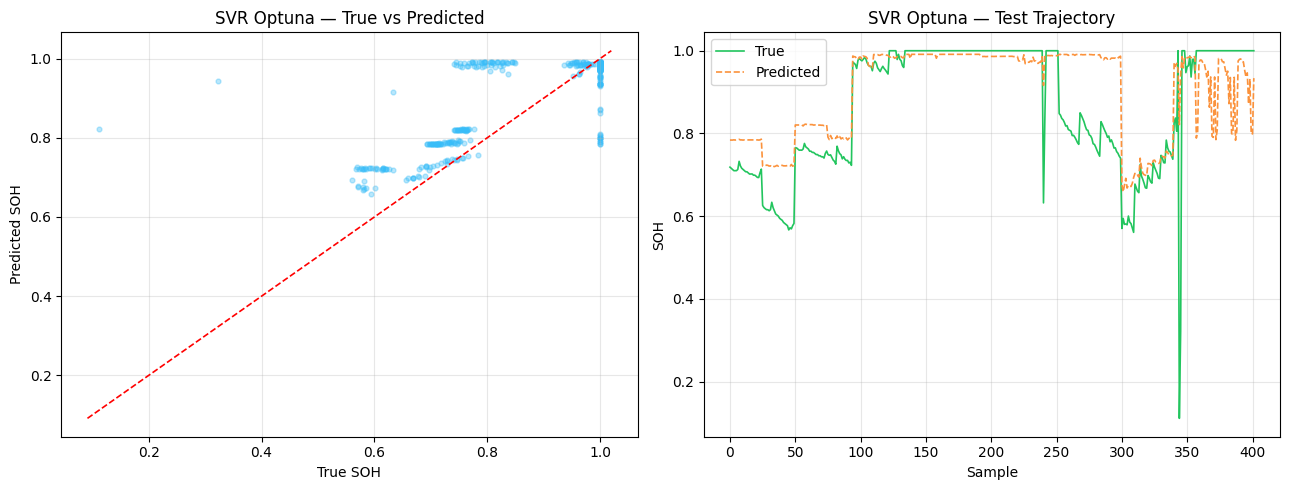

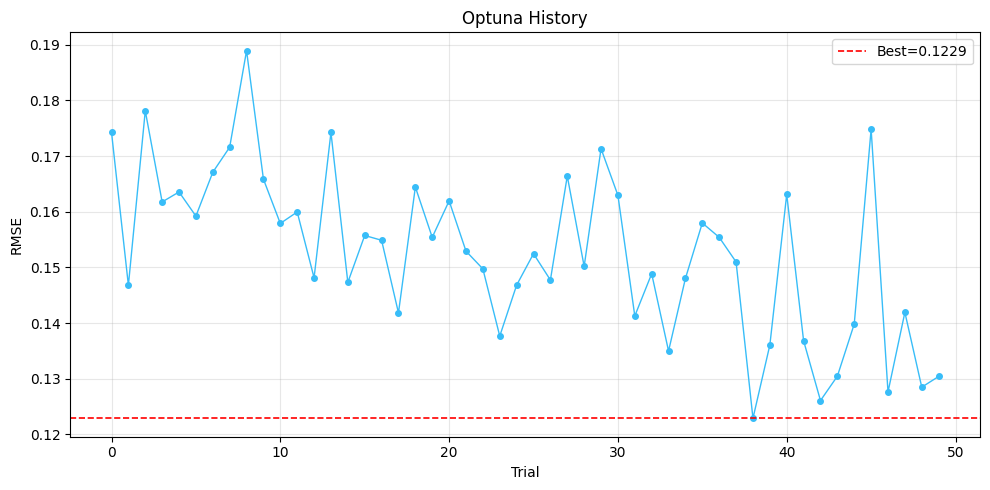

In [165]:
print(f'Optimising: {best_ml_name}')

def rf_obj(trial):
    m = RandomForestRegressor(
        n_estimators=trial.suggest_int('n_estimators',100,800),
        max_depth=trial.suggest_int('max_depth',4,24),
        min_samples_leaf=trial.suggest_int('min_samples_leaf',1,8),

        # FIXED
        max_features=trial.suggest_categorical(
            'max_features', ['sqrt','log2',1.0]
        ),

        n_jobs=-1,
        random_state=SEED
    )
    m.fit(X_train,y_train)
    return np.sqrt(mean_squared_error(y_val,m.predict(X_val)))


def xgb_obj(trial):
    m = GradientBoostingRegressor(
        n_estimators=trial.suggest_int('n_estimators',100,800),
        max_depth=trial.suggest_int('max_depth',3,10),
        learning_rate=trial.suggest_float('learning_rate',0.005,0.2,log=True),
        subsample=trial.suggest_float('subsample',0.5,1.0),
        min_samples_leaf=trial.suggest_int('min_samples_leaf',1,8),
        random_state=SEED
    )
    m.fit(X_train,y_train)
    return np.sqrt(mean_squared_error(y_val,m.predict(X_val)))


# choose objective
objective = rf_obj if best_ml_name == 'Random Forest' else xgb_obj

study = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=SEED)
)

study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f'Best params: {study.best_params}')
print(f'Best RMSE  : {study.best_value:.4f}')


# rebuild model safely
bp = study.best_params

if best_ml_name == 'Random Forest':
    opt_m = RandomForestRegressor(
        n_estimators=bp['n_estimators'],
        max_depth=bp['max_depth'],
        min_samples_leaf=bp['min_samples_leaf'],
        max_features=bp['max_features'],
        n_jobs=-1,
        random_state=SEED
    )
else:
    opt_m = GradientBoostingRegressor(
        n_estimators=bp['n_estimators'],
        max_depth=bp['max_depth'],
        learning_rate=bp['learning_rate'],
        subsample=bp['subsample'],
        min_samples_leaf=bp['min_samples_leaf'],
        random_state=SEED
    )

opt_m.fit(X_train,y_train)
yp = opt_m.predict(X_test)

res = evaluate(y_test, yp, f'{best_ml_name} (Optuna)')
all_results.append(res)

plot_pred(y_test, yp, f'{best_ml_name} Optuna')

pickle.dump(opt_m, open(MODELS/'optimized_ml.pkl','wb'))


# history plot
fig, ax = plt.subplots(figsize=(10,5))
td = study.trials_dataframe().dropna(subset=['value'])

ax.plot(td['number'], td['value'], 'o-', ms=4, color='#38bdf8', lw=1)
ax.axhline(study.best_value, color='red', ls='--', lw=1.2,
           label=f'Best={study.best_value:.4f}')

ax.set_xlabel('Trial')
ax.set_ylabel('RMSE')
ax.set_title('Optuna History')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(PLOTS/'optuna_history.png', dpi=150)
plt.show()

##  Model Comparison

,model,MAE,RMSE,R2,MAPE
0,CNN+LSTM,0.0279,0.0391,0.9350,3.76%
1,LSTM,0.0303,0.0403,0.9308,4.24%
2,Transformer,0.0351,0.0430,0.9213,4.58%
3,SVR (Optuna),0.0673,0.1036,0.5360,10.32%


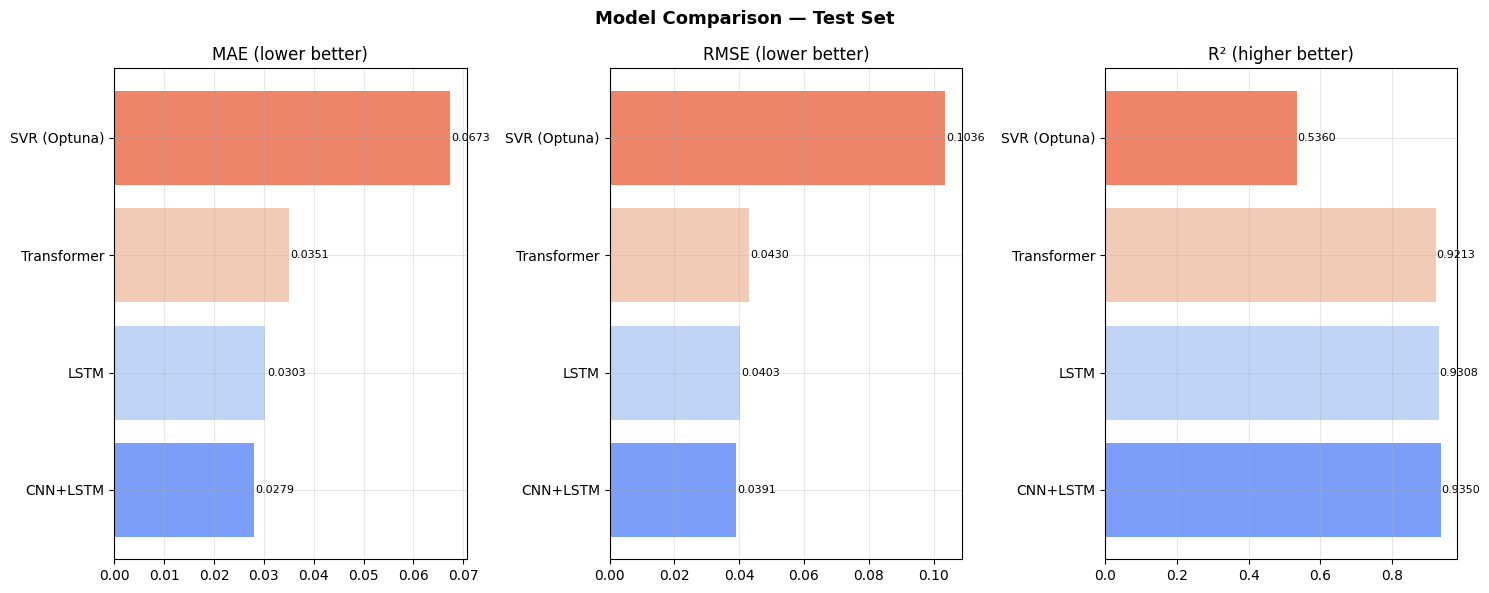


Best model : CNN+LSTM
  MAE  = 0.0279
  RMSE = 0.0391
  R²   = 0.9350
  MAPE = 3.76%

All outputs → /kaggle/working/results/


In [166]:
results_df = pd.DataFrame(all_results).sort_values('RMSE').reset_index(drop=True)

display(results_df
    .style
    .background_gradient(subset=['MAE','RMSE'], cmap='RdYlGn_r')
    .background_gradient(subset=['R2'],         cmap='RdYlGn')
    .format({'MAE':'{:.4f}','RMSE':'{:.4f}','R2':'{:.4f}','MAPE':'{:.2f}%'}))

fig, axes = plt.subplots(1,3,figsize=(15,6))
pal = sns.color_palette('coolwarm', len(results_df))
for ax, metric in zip(axes, ['MAE','RMSE','R2']):
    sd = results_df.sort_values(metric, ascending=(metric!='R2'))
    bars = ax.barh(sd['model'], sd[metric], color=pal)
    ax.set_title(f'{metric} (lower better)' if metric!='R2' else 'R² (higher better)')
    for bar,val in zip(bars, sd[metric]):
        ax.text(bar.get_width()+0.0003, bar.get_y()+bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=8)
    ax.grid(alpha=0.3)
plt.suptitle('Model Comparison — Test Set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(PLOTS/'model_comparison.png', dpi=150)
plt.show()

results_df.to_csv(OUT/'model_comparison.csv', index=False)
best_row = results_df.iloc[0]
print(f"\n{'='*50}")
print(f"Best model : {best_row['model']}")
print(f"  MAE  = {best_row['MAE']:.4f}")
print(f"  RMSE = {best_row['RMSE']:.4f}")
print(f"  R²   = {best_row['R2']:.4f}")
print(f"  MAPE = {best_row['MAPE']:.2f}%")
print(f"\nAll outputs → /kaggle/working/results/")